# NYC Airbnb — Exploratory Data Analysis

**Project:** Data-backed recommendation for a property management company on which NYC neighborhood x room-type segments to prioritize for new host listings.

**This notebook:**
1. Connect to the `data_analyst_project` PostgreSQL database.
2. Investigate the raw listings data to validate and extend the SQL cleaning rules (see `sql/02_data_cleaning.sql`) — a second, different tool cross-checking the first, rather than trusting SQL blindly.
3. Visualize the `price` distribution to detect outliers properly (something SQL aggregates alone can't show well), and decide how to handle them.
4. Explore the final cleaned dataset visually — the Python counterpart to the SQL exploration in `sql/03_eda_queries.sql`.

In [1]:
# Core libraries for this notebook:
# - pandas: loads SQL query results into a DataFrame (a table we can manipulate in Python)
# - sqlalchemy: manages the database connection
# - getpass: securely prompts for the DB password without ever saving it in this file
# - matplotlib / seaborn: plotting, for the outlier visualization later in this notebook

import pandas as pd
from sqlalchemy import create_engine
import getpass
import matplotlib.pyplot as plt
import seaborn as sns

## Connect to PostgreSQL

We build a **connection string** (a URL-like text SQLAlchemy uses to find and log into the database) in the form:

`postgresql+psycopg2://<user>:<password>@<host>:<port>/<database>`

The password is captured with `getpass.getpass()`, which prompts you to type it when this cell runs, and hides the characters as you type (like a terminal password prompt). It is never written into this notebook file — this matters because this repo is public on GitHub, and hardcoding a real password into a file that gets committed would expose it permanently in the commit history, even if removed in a later commit.

In [2]:
db_user = "postgres"
db_password = getpass.getpass("Enter your PostgreSQL password: ")
db_host = "localhost"
db_port = "5432"
db_name = "data_analyst_project"

engine = create_engine(f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}")

# Quick connection test -- if this fails, the password or connection details are wrong
with engine.connect() as conn:
    print("Connected successfully.")

Connected successfully.


## Load the data for investigation

`pd.read_sql()` runs a SQL query through our connection and returns the result as a pandas DataFrame — the in-memory table structure pandas, matplotlib, and seaborn all understand.

We deliberately load from **`listings_raw`** here, applying only the first cleaning rule (`price IS NOT NULL`). The purpose of this section is to investigate the data *as it stood before the remaining cleaning rules were decided*. Loading the finished `listings_clean` table instead would mean "discovering" problems that had already been removed from it — which would prove nothing. The cleaned table is loaded further down, once the investigation has justified how it was built.

In [3]:
df = pd.read_sql("SELECT * FROM listings_raw WHERE price IS NOT NULL;", engine)
df.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,3605524,"Midtown Apt, Quiet, Walk to Subway",17958831,1.463033e+18,Tomer,Manhattan,Kips Bay,40.74156,-73.97836,Entire home/apt,149.0,30.0,138,2020-05-03,0.95,1,305,0,NaN
1,3616173,Comfortable Private Bedroom you'll love -1 G...,2383619,1.462524e+18,Elms,Brooklyn,Clinton Hill,40.68190,-73.96464,Private room,105.0,30.0,118,2026-06-15,0.81,1,127,2,NaN
2,3624387,"Beautiful Apt x Rent in Astoria, NY",4666670,1.462537e+18,Jeanny,Queens,Long Island City,40.76514,-73.93361,Entire home/apt,180.0,30.0,29,2023-05-25,0.20,2,365,0,NaN
3,3625870,Modern Style Meets Old World,18264329,1.463040e+18,Joaquin,Brooklyn,Sunset Park,40.65023,-74.00613,Private room,209.0,3.0,142,2026-08-03,0.98,1,293,21,OSE-STRREG-0000307
4,3626426,Afi Apartments 2 Bedroom apartment Upper East ...,13347167,1.462909e+18,"Jose,Antonio",Manhattan,Upper East Side,40.77130,-73.95753,Entire home/apt,165.0,30.0,11,2025-06-01,0.09,33,360,0,NaN


## Validate the price filter, independently

SQL reported **20,331 rows** remaining after excluding listings with a null `price` (9,903 removed from the 30,234 raw records). We confirm that here in pandas — a genuine second check using a different tool, rather than assuming the SQL was correct.

In [4]:
print("Shape (rows, columns):", df.shape)
print("\nNull counts per column:")
print(df.isnull().sum())
print("\nColumn data types:")
print(df.dtypes)

Shape (rows, columns): (20331, 19)

Null counts per column:
id                                    0
name                                  0
host_id                               0
host_profile_id                     260
host_name                           508
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        3
number_of_reviews                     0
last_review                        5389
reviews_per_month                  5389
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                           15609
dtype: int64

Column data types:
id                                  int64
name                                  str
host_id                             int64
host_profile_id      

## Detect price outliers

`.describe()` gives a fuller statistical picture in one call: count, mean, standard deviation, and the quartiles (25th/50th/75th percentile) — the values that split the data into four equal-sized groups.

Comparing the 75th percentile to the maximum is a quick outlier smell test: if the max is *wildly* larger than the 75th percentile, a small number of extreme values are likely dragging the average upward. Both tails are worth watching in the output below — the top end for extreme luxury pricing, and the bottom end for prices too low to be a real nightly rate. Each is investigated separately.

In [5]:
df['price'].describe()

count    20331.000000
mean       267.370124
std        530.040784
min          5.000000
25%        101.000000
50%        175.000000
75%        287.000000
max      31211.000000
Name: price, dtype: float64

## Visualize the distribution

Numbers alone can hide a distribution's shape. A histogram (bars showing how many listings fall into each price range) makes it visually obvious where most listings sit and how far the extreme values stray from the bulk of the data. We restrict the x-axis to under $1,000 first, since a few extreme outliers above that would otherwise squash the entire chart into an unreadable sliver.

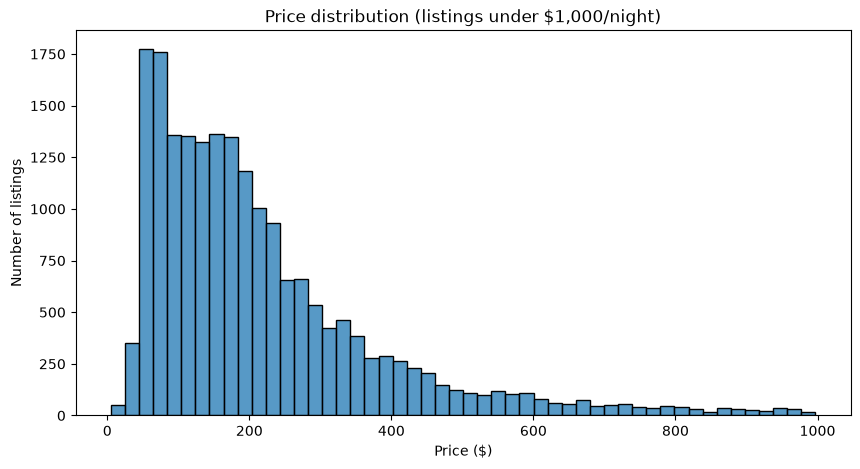

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['price'] < 1000]['price'], bins=50)
plt.title('Price distribution (listings under $1,000/night)')
plt.xlabel('Price ($)')
plt.ylabel('Number of listings')
plt.show()

## Define outliers statistically: the IQR method

Rather than picking an outlier cutoff by eyeballing the chart, we use the **IQR (Interquartile Range) method** — a standard statistical technique:

1. Find Q1 (25th percentile) and Q3 (75th percentile) of price.
2. IQR = Q3 − Q1 (the range containing the "middle 50%" of the data).
3. Anything below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is flagged as a statistical outlier. The `1.5` multiplier is a widely-used convention (it's the same rule a box plot uses to decide what points to draw as individual dots outside the "whiskers").


In [7]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Outlier bounds: below {lower_bound} or above {upper_bound}")

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"\nNumber of price outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of listings)")

Q1: 101.0, Q3: 287.0, IQR: 186.0
Outlier bounds: below -178.0 or above 566.0

Number of price outliers: 1512 (7.4% of listings)


## Decision: don't delete high-price outliers

Being a *statistical* outlier doesn't mean *bad data*. A $2,000/night Manhattan penthouse is a real listing -- and it's arguably one of the exact high-value segments our business question (highest average price by segment) is trying to find. Deleting every expensive listing would throw away the signal we're looking for.

**Decision:** keep all rows. When answering price-related business questions later, use the **median** price per segment instead of the mean -- median is naturally resistant to a handful of extreme values, giving a "typical listing" figure without needing to discard real data.

That still leaves the bottom of the range. The minimum price above wasn't flagged as a *statistical* outlier (the IQR lower bound is negative, so nothing can fall below it), but it is suspicious on business grounds: a genuinely bookable NYC listing at a few dollars a night is implausible. Let's inspect the low-priced listings directly rather than guessing.

In [8]:
low_price = df[df['price'] < 20].sort_values('price')
print(f"Listings under $20/night: {len(low_price)}")
low_price[['id', 'name', 'neighbourhood', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'availability_365']]

Listings under $20/night: 32


,id,name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365
8761,718389176579416848,Very good atmosphere,Harlem,Private room,5.0,365.0,0,365
168,3891031,LAST DAY TO BOOK Bedroom on Wall St,Financial District,Private room,7.0,365.0,11,365
9554,787927073413255581,Private Room Near JFK NY USA,Ozone Park,Private room,10.0,180.0,9,353
14496,1214636499668232791,Unfurnished 2BR UES 12 month MIN,Upper East Side,Entire home/apt,10.0,364.0,0,364
10559,871990853610302281,Detached Cozy Private Studio,Howard Beach,Entire home/apt,11.0,365.0,0,365
2366,19413467,Nice Room (2 people) with private Bathroom in NYC,Upper West Side,Private room,11.0,360.0,7,365
7271,547058790481548248,"Great Location, Clean Room w Private Bathroom",Chelsea,Private room,11.0,360.0,0,364
13992,1174252633024473480,Charming Oasis by the Park,Washington Heights,Entire home/apt,11.0,365.0,0,365
8467,691569646575996680,Semi-Private Basic - Midtown Manhattan,Midtown,Private room,11.0,180.0,0,364
10692,883607653341164621,Gorgeous 1 Bedroom apartment,East New York,Entire home/apt,12.0,150.0,1,285


## Investigate the minimum_nights pattern

Every listing in that low-price group carries an extremely high `minimum_nights` value. NYC has short-term rental regulations (Local Law 18) that specifically restrict rentals *under 30 nights*. A common, well-documented workaround is hosts listing what is really a long-term rental through Airbnb, with an artificially low nightly price, since nobody actually books it night-by-night -- the stay is effectively required to be months long.

Let's check how widespread this is across the *whole* dataset, not just the cheapest listings.

In [9]:
long_stay = df[df['minimum_nights'] >= 30]
short_stay = df[df['minimum_nights'] < 30]

print(f"Listings with minimum_nights >= 30: {len(long_stay)} ({len(long_stay)/len(df)*100:.1f}% of all listings)")
print(f"Listings with minimum_nights < 30 (true short-term): {len(short_stay)} ({len(short_stay)/len(df)*100:.1f}% of all listings)")

print("\nMedian price -- long-stay (>=30 nights) group:", long_stay['price'].median())
print("Median price -- short-stay (<30 nights) group:", short_stay['price'].median())

Listings with minimum_nights >= 30: 15048 (74.0% of all listings)
Listings with minimum_nights < 30 (true short-term): 5280 (26.0% of all listings)

Median price -- long-stay (>=30 nights) group: 145.0
Median price -- short-stay (<30 nights) group: 275.0


## Decision: exclude long-stay listings from the analysis

Go back to Step 1: our stakeholder is deciding where to sign new **short-term rental** hosts. A listing requiring a 30+ night minimum stay isn't operating in that market at all -- it behaves completely differently (no real nightly turnover, review activity doesn't reflect booking frequency the same way, and price isn't a real nightly rate).

**Decision:** exclude listings with `minimum_nights >= 30` from the analysis dataset entirely, not just for price -- this affects demand and saturation metrics too, since a "listing" that's really a long-term lease shouldn't count toward short-term market opportunity in any of our 5 business questions.

This is a cleaning rule that belongs in SQL (the canonical `listings_clean` table), not just filtered ad-hoc here in Python -- so we'll add it to `sql/02_data_cleaning.sql` and rebuild `listings_clean`, then reload it here to confirm.

## Rebuild and reload the cleaned table

The `minimum_nights < 30` rule was added to `sql/02_data_cleaning.sql` and `listings_clean` was rebuilt from `listings_raw` with both rules applied.

We now load that canonical cleaned table. **Everything below this point — and the Power BI dashboard — is built on this dataset.** Any nulls that remain are legitimate rather than breakage: not every listing has a host profile on file, and not every listing has ever received a review, so `last_review` and `reviews_per_month` are correctly empty for those.

In [10]:
# Reload the canonical cleaned table -- every section below this point uses it.
df = pd.read_sql("SELECT * FROM listings_clean;", engine)

print("Shape (rows, columns):", df.shape)
print("\nNull counts per column:")
print(df.isnull().sum())

Shape (rows, columns): (5280, 18)

Null counts per column:
id                                  0
name                                0
host_id                             0
host_profile_id                   260
host_name                         508
neighbourhood_group                 0
neighbourhood                       0
latitude                            0
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                       727
reviews_per_month                 727
calculated_host_listings_count      0
availability_365                    0
number_of_reviews_ltm               0
dtype: int64


## EDA — Python Visualization Layer

We already ran **EDA queries in SQL** (`sql/03_eda_queries.sql`): borough counts, room-type counts, median vs mean price, median price by borough. Those queries produced the *numbers*. This section covers the same underlying facts, turned into pictures.

**Why do the same exploration twice, in two different tools?**

- SQL is exact and fast at aggregation — it can group and summarize millions of rows in milliseconds, but a table of numbers doesn't make skew, imbalance, or shape jump out.
- A chart makes proportion and scale immediately obvious in a way a results table doesn't. Compare "Manhattan 2776, Brooklyn 1488, Queens 819, Bronx 145, Staten Island 52" as a table versus as a bar chart — the imbalance registers instantly in the second.

Neither replaces the other. SQL EDA is the fast way to get the numbers while exploring; visuals are what make a pattern communicable to someone else — a teammate, a stakeholder, or downstream in Power BI.

### Bar chart: listings by borough

**What we're doing:** plotting the same borough counts from SQL Query 1 (Manhattan 2776, Brooklyn 1488, Queens 819, Bronx 145, Staten Island 52) as a bar chart, sorted from most to fewest listings.

**Why:** this is the first and most basic fact about our data's shape — where the listings actually are. Before answering any business question, we need to see (not just read a table showing) that Manhattan and Brooklyn dominate the market and Staten Island is barely represented at all. That imbalance will matter later when we compare metrics *within* boroughs — a borough with 52 listings needs to be read differently than one with 2,776.

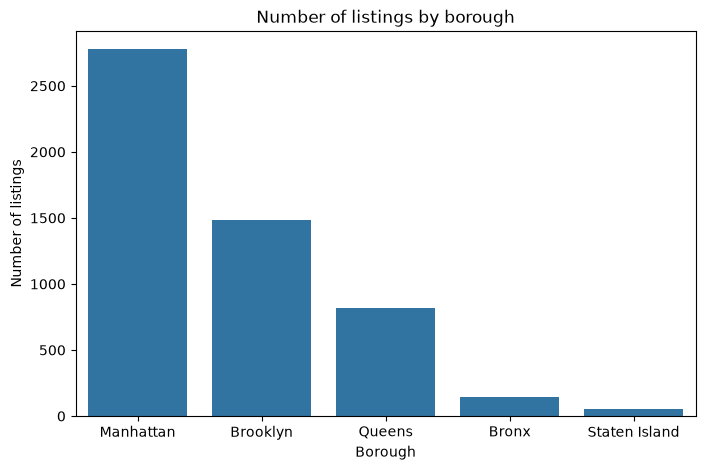

In [11]:
plt.figure(figsize=(8, 5))

# value_counts() on neighbourhood_group gives us the same borough counts as SQL Query 1,
# and .index gives us that ordering (most listings first) to pass into `order=` below --
# without this, seaborn would default to alphabetical order, which hides the imbalance.
order = df['neighbourhood_group'].value_counts().index

# countplot literally counts rows per category and draws a bar per count in one call --
# it's doing the COUNT(*) ... GROUP BY from SQL Query 1, but drawing it instead of printing it.
sns.countplot(data=df, x='neighbourhood_group', order=order)

plt.title('Number of listings by borough')
plt.xlabel('Borough')
plt.ylabel('Number of listings')
plt.show()

### Bar chart: listings by room type

**What we're doing:** the same kind of count-and-plot as the borough chart, but grouped by `room_type` instead — mirroring SQL Query 2 (Private room 3281, Entire home/apt 1539, Hotel room 422, Shared room 38).

**Why:** room type is the other main way this market splits. We'd expect pricing, demand, and guest expectations to differ sharply between renting an entire apartment versus a private room in someone's home versus a hotel room listed through Airbnb. Seeing the split visually, before Step 6 slices price and demand by room type, tells us in advance which segments even have enough listings to draw a reliable conclusion from — "Hotel room" and "Shared room" together are a small fraction of the market, so any statistic computed on them alone (e.g. "average price of shared rooms") should be read with that small sample size in mind.

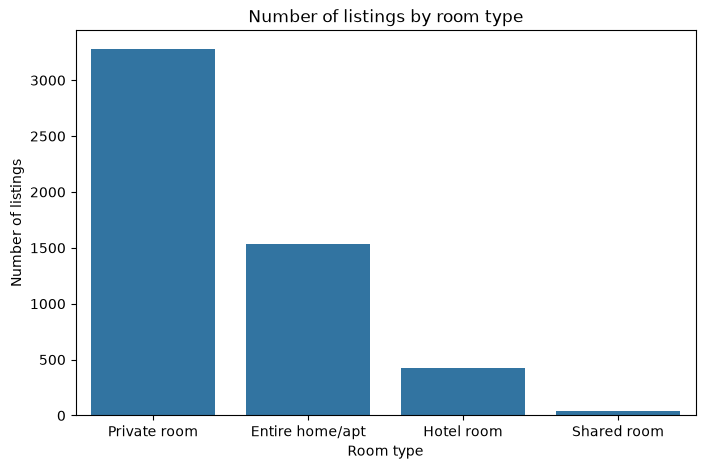

In [12]:
plt.figure(figsize=(8, 5))

# Same pattern as the borough chart: order by count (most common room type first),
# not alphabetically, so the imbalance is visible at a glance.
order = df['room_type'].value_counts().index

sns.countplot(data=df, x='room_type', order=order)

plt.title('Number of listings by room type')
plt.xlabel('Room type')
plt.ylabel('Number of listings')
plt.show()

### Boxplot: price distribution by borough

**What we're doing:** a boxplot of `price` grouped by `neighbourhood_group`, restricted to listings under $1,000/night (same reasoning as the earlier histogram — a handful of extreme high-price listings would otherwise squash the box for every borough into an unreadable sliver near zero).

**Why a boxplot instead of another bar chart:** SQL Query 4 already told us the *median* price per borough (Manhattan $328, Brooklyn $252, Queens $192, Bronx $166, Staten Island $164) — one number each. A boxplot shows much more per borough in a single picture:

- The **line inside the box** is the median — the same number SQL gave us.
- The **box itself** spans the interquartile range (IQR) — the middle 50% of listings in that borough, from Q1 to Q3.
- The **whiskers** extend to the typical range beyond the box.
- **Individual dots** past the whiskers are statistical outliers for that borough specifically (recall: we decided in Step 4 not to delete these — they're real high-value listings, not data errors).

A bar chart of medians can't show you any of that spread — it would make Manhattan and Brooklyn look like two single numbers, when really one of them might have far more pricing variability than the other. That's useful for a stakeholder: a borough with a tight, predictable price range is a very different opportunity than one with the same median but a huge spread.

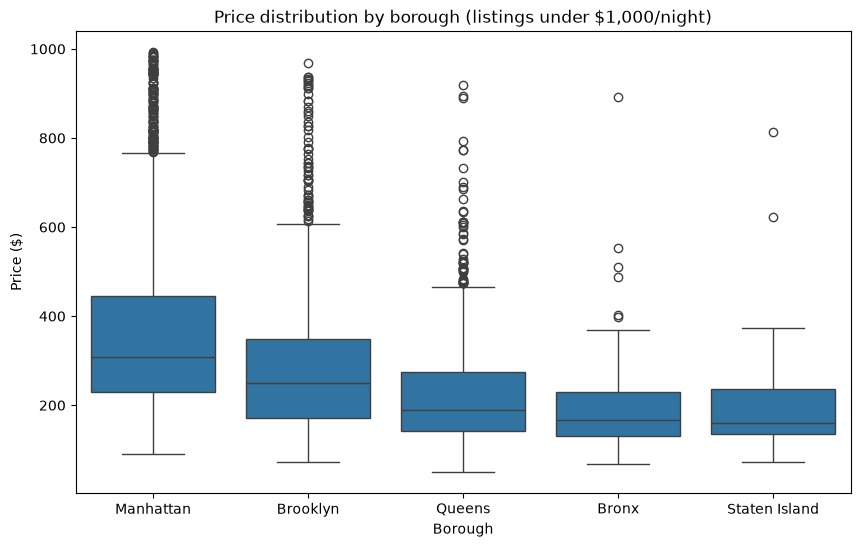

In [13]:
plt.figure(figsize=(10, 6))

# Same borough ordering convention as our earlier bar chart -- highest listing count
# first -- so all our charts stay visually consistent with each other.
order = df['neighbourhood_group'].value_counts().index

# Restrict to price < 1000 for the same reason as the earlier histogram: a few extreme
# outliers would otherwise stretch the y-axis so far that every box gets crushed flat.
sns.boxplot(data=df[df['price'] < 1000], x='neighbourhood_group', y='price', order=order)

plt.title('Price distribution by borough (listings under $1,000/night)')
plt.xlabel('Borough')
plt.ylabel('Price ($)')
plt.show()